In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [12]:
# Load the Breast Cancer Wisconsin Dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df["target"] = data.target

# Create readable diagnosis labels
df["diagnosis"] = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

print("Dataset Shape:", df.shape)

print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# Save dataset
df.to_csv("breast_cancer_data.csv", index=False)

print("\nDataset saved successfully.")

Dataset Shape: (569, 32)

Diagnosis Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Dataset saved successfully.


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

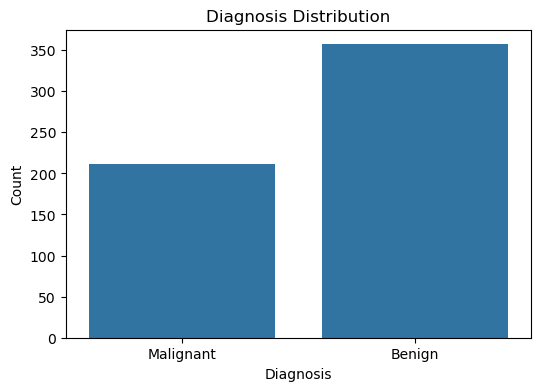

In [13]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())

print("\nFirst Five Rows")
print(df.head())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

# Diagnosis Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

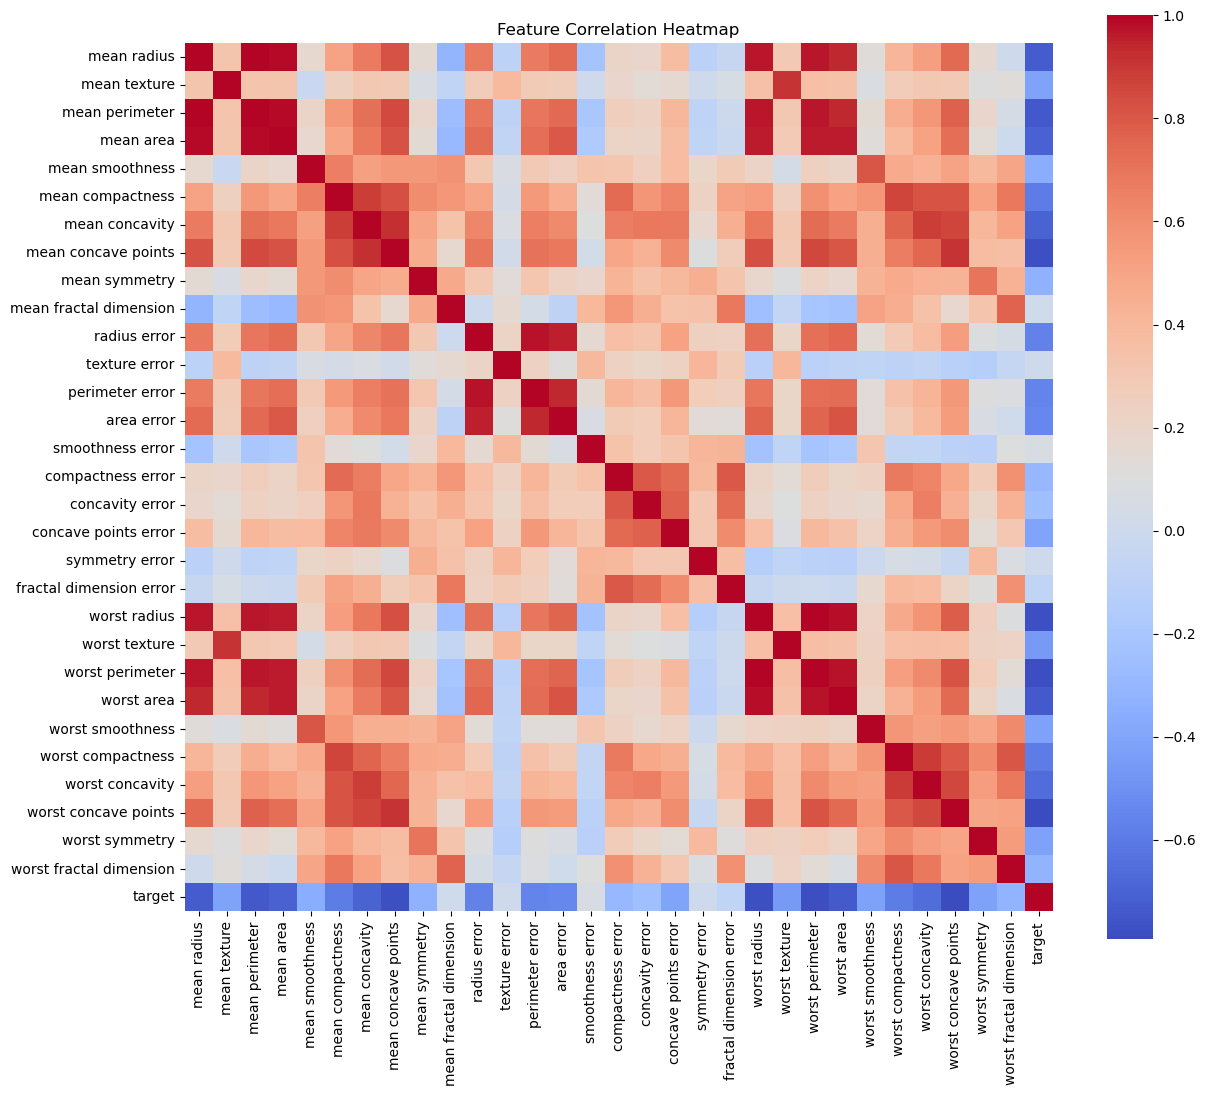

In [14]:
plt.figure(figsize=(14,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [15]:
X = df.drop(columns=["target", "diagnosis"])

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


In [16]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


LOGISTIC REGRESSION
Accuracy: 98.25%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



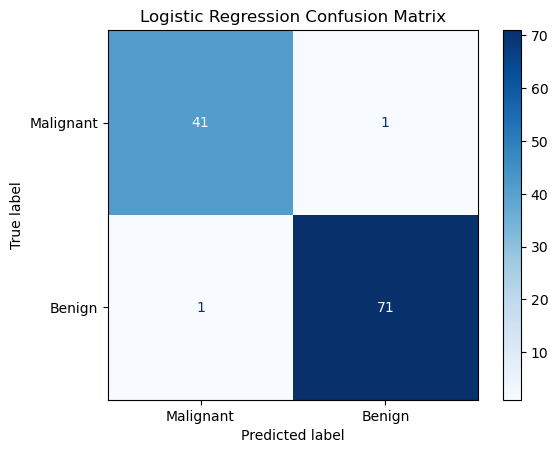

RANDOM FOREST
Accuracy: 95.61%
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



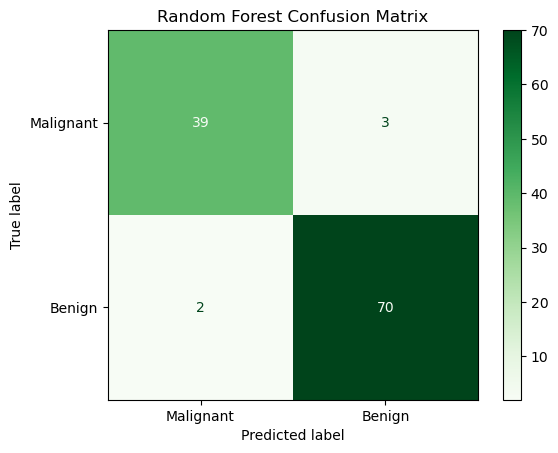

In [17]:
# Logistic Regression Accuracy

log_acc = accuracy_score(y_test, log_pred)

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

print(f"Accuracy: {log_acc:.2%}")

print(classification_report(y_test, log_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    display_labels=["Malignant","Benign"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()


# Random Forest Accuracy

rf_acc = accuracy_score(y_test, rf_pred)

print("="*60)
print("RANDOM FOREST")
print("="*60)

print(f"Accuracy: {rf_acc:.2%}")

print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Malignant","Benign"],
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

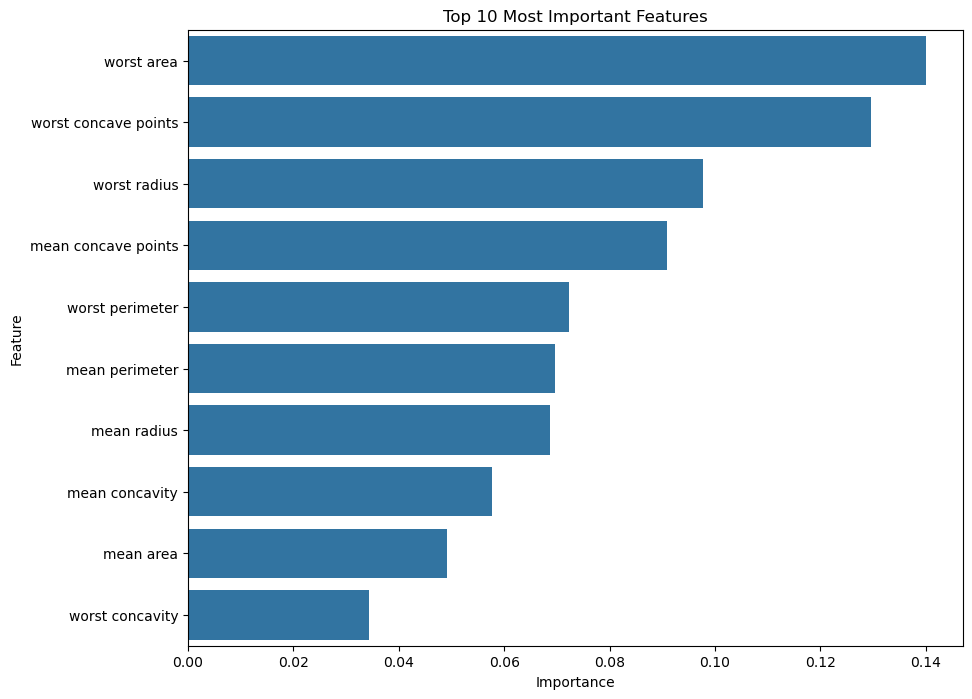

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

In [19]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"Logistic Regression Accuracy : {log_acc:.2%}")

print(f"Random Forest Accuracy      : {rf_acc:.2%}")

if log_acc > rf_acc:
    print("\nBest Performing Model: Logistic Regression")
else:
    print("\nBest Performing Model: Random Forest")

print("\nConclusion:")

print(
    "Both models achieved excellent predictive performance on the "
    "Breast Cancer Wisconsin dataset. "
    "This project demonstrates how Machine Learning can assist "
    "in disease classification while emphasizing that these models "
    "are intended for educational purposes rather than clinical diagnosis."
)

print("\nProject completed successfully!")

PROJECT SUMMARY
Logistic Regression Accuracy : 98.25%
Random Forest Accuracy      : 95.61%

Best Performing Model: Logistic Regression

Conclusion:
Both models achieved excellent predictive performance on the Breast Cancer Wisconsin dataset. This project demonstrates how Machine Learning can assist in disease classification while emphasizing that these models are intended for educational purposes rather than clinical diagnosis.

Project completed successfully!
